### Testing SUMO accessibility via python code.

In [12]:
import os
import sys
import traci

# Check SUMO_HOME
if 'SUMO_HOME' in os.environ:
    tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
    sys.path.append(tools)
else:
    sys.exit("Please declare environment variable 'SUMO_HOME'")

# Choose sumo or sumo-gui
sumoBinary = "sumo-gui"   # use "sumo" for command line

sumoCmd = [sumoBinary, "-c", "../nets/unrestricted_right_xml_gen/unrestricted_right.sumocfg", "--delay=50", "--start", "--quit-on-end"]

# Start SUMO
traci.start(sumoCmd)

step = 0
while step < 3600:
    traci.simulationStep()
    step += 1
    
    # vehicle_ids = traci.vehicle.getIDList()
    # print("Vehicles in simulation:", vehicle_ids)

    # print(traci.lane.getLastStepHaltingNumber("westJunction_1"))  # Example: get queue length for a specific lane

traci.close()

In [11]:
traci.close()

#### Setting up SUMO RL environment for running simulation

In [ ]:
# Paths for SUMO configuration and network files
import os

net_file = "../nets/unrestricted_right_xml_gen/unrestricted_right.net.xml"
route_file = "../nets/unrestricted_right_xml_gen/unrestricted_right.rou.xml"
output_file = "../outputs/sumo_rl_outputs.csv"
# sumocfg_file = "../nets/unrestricted_right_xml_gen/unrestricted_right.sumocfg"

# print("Net file path:", net_file,"Route file path:", route_file, "Output file path:", output_file, sep="\n")


Net file path:
../nets/unrestricted_right_xml_gen/unrestricted_right.net.xml
Route file path:
../nets/unrestricted_right_xml_gen/unrestricted_right.rou.xml
Output file path:
../outputs/sumo_rl_outputs.csv


In [5]:
import os
import sys
import numpy as np
from pathlib import Path
from gymnasium import spaces
from sumo_rl import SumoEnvironment
from sumo_rl.environment.traffic_signal import TrafficSignal
from sumo_rl.environment.observations import ObservationFunction

# ── SUMO setup ─────────────────────────────────────────────────────────────────
os.environ["SUMO_HOME"] = "D:\\SUMO"
sys.path.append(os.path.join(os.environ["SUMO_HOME"], "tools"))

# ── Paths ──────────────────────────────────────────────────────────────────────
try:
    base = Path(__file__).resolve().parent.parent
except NameError:
    base = Path.cwd().parent

folder_name = "unrestricted_right_xml_gen"
net_name    = "unrestricted_right"

NET_FILE     = str(base / "nets"    / folder_name / f"{net_name}.net.xml")
ROUTE_FILE   = str(base / "nets"    / folder_name / f"{net_name}.rou.xml")
OUT_CSV      = str(base / "outputs" / "sumo_rl_outputs")

Path(base / "outputs").mkdir(parents=True, exist_ok=True)

assert Path(NET_FILE).exists(),   f"net_file not found:   {NET_FILE}"
assert Path(ROUTE_FILE).exists(), f"route_file not found: {ROUTE_FILE}"
print(f"✓ net_file   : {NET_FILE}")
print(f"✓ route_file : {ROUTE_FILE}")
print(f"✓ SUMO_HOME  : {os.environ.get('SUMO_HOME')}")


# ── Reward function ────────────────────────────────────────────────────────────
def reward_function(traffic_signal: TrafficSignal) -> float:
    MAX_WAITING   = 300.0
    MAX_QUEUE     = 20.0
    MAX_PRESSURE  = 10.0
    MAX_COLLISION = 1.0

    waiting_time_raw = traffic_signal.get_accumulated_waiting_time_per_lane()
    if isinstance(waiting_time_raw, dict):
        total_waiting = sum(waiting_time_raw.values())
    elif isinstance(waiting_time_raw, (int, float)):
        total_waiting = float(waiting_time_raw)
    else:
        total_waiting = float(sum(waiting_time_raw))

    queue_length = float(sum(
        traffic_signal.sumo.lane.getLastStepHaltingNumber(lane)
        for lane in traffic_signal.lanes
    ))

    pressure_raw = traffic_signal.get_pressure()
    if isinstance(pressure_raw, list):
        pressure = float(sum(pressure_raw))
    elif isinstance(pressure_raw, dict):
        pressure = float(sum(pressure_raw.values()))
    else:
        pressure = float(pressure_raw)

    collision_count = float(len(traffic_signal.sumo.simulation.getCollisions()))

    norm_waiting   = min(total_waiting   / MAX_WAITING,   1.0)
    norm_queue     = min(queue_length    / MAX_QUEUE,     1.0)
    norm_pressure  = min(abs(pressure)   / MAX_PRESSURE,  1.0)
    norm_collision = min(collision_count / MAX_COLLISION, 1.0)

    return -(
        norm_waiting   * 0.3 +
        norm_queue     * 0.3 +
        norm_pressure  * 0.2 +
        norm_collision * 0.2
    )


# ── Observation function ───────────────────────────────────────────────────────
class CustomObservationFunction(ObservationFunction):
    def __init__(self, ts: TrafficSignal):
        super().__init__(ts)

    def __call__(self) -> np.ndarray:
        ts = self.ts
        phase_id = [1 if ts.green_phase == i else 0 for i in range(ts.num_green_phases)]
        density  = [
            ts.sumo.lane.getLastStepVehicleNumber(lane) / (ts.sumo.lane.getLength(lane) / 7.5)
            for lane in ts.lanes
        ]
        queue = [
            ts.sumo.lane.getLastStepHaltingNumber(lane) / (ts.sumo.lane.getLength(lane) / 7.5)
            for lane in ts.lanes
        ]
        speed = [
            ts.sumo.lane.getLastStepMeanSpeed(lane) /
            max(ts.sumo.lane.getMaxSpeed(lane), 1e-6)
            for lane in ts.lanes
        ]
        return np.clip(np.array(phase_id + density + queue + speed, dtype=np.float32), 0.0, 1.0)

    def observation_space(self) -> spaces.Box:
        size = self.ts.num_green_phases + 3 * len(self.ts.lanes)
        return spaces.Box(low=0.0, high=1.0, shape=(size,), dtype=np.float32)


# ── Environment factory ────────────────────────────────────────────────────────
# No EnvGenerator class — use make_env() directly so paths are
# always module-level str constants, never Path objects
def make_env(out_csv_name: str = OUT_CSV, duration: int = 3600, use_gui: bool = False):
    def _init():
        return SumoEnvironment(
            net_file=NET_FILE,          # str ✓
            route_file=ROUTE_FILE,      # str ✓
            out_csv_name=out_csv_name,  # str ✓
            single_agent=True,
            use_gui=use_gui,
            num_seconds=duration,
            delta_time=5,
            yellow_time=2,
            min_green=5,
            reward_fn=reward_function,
            observation_class=CustomObservationFunction,
            sumo_warnings=False,
        )
    return _init


# ── Smoke-test ─────────────────────────────────────────────────────────────────
env = make_env()()      # make_env() returns _init, second () calls it

obs, info = env.reset()
print(f"\n✓ Reset  | obs shape : {obs.shape}")

print("\nRunning 5 random steps ...")
for step in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(
        f"  Step {step+1:02d} | "
        f"action: {action} | "
        f"reward: {reward:.3f} | "
        f"terminated: {terminated}"
    )
    if terminated or truncated:
        obs, info = env.reset()

env.close()
print("\n✓ Smoke-test complete.")

✓ net_file   : d:\Robotic_Sensing_and Transfer_Learning\Simulation\nets\unrestricted_right_xml_gen\unrestricted_right.net.xml
✓ route_file : d:\Robotic_Sensing_and Transfer_Learning\Simulation\nets\unrestricted_right_xml_gen\unrestricted_right.rou.xml
✓ SUMO_HOME  : D:\SUMO

✓ Reset  | obs shape : (14,)

Running 5 random steps ...
  Step 01 | action: 0 | reward: -0.080 | terminated: False
  Step 02 | action: 1 | reward: -0.120 | terminated: False
  Step 03 | action: 1 | reward: -0.120 | terminated: False
  Step 04 | action: 0 | reward: -0.098 | terminated: False
  Step 05 | action: 1 | reward: -0.197 | terminated: False

✓ Smoke-test complete.


In [1]:
# Trial Algrithm PPO 
import os
import sys
from pathlib import Path
from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
import numpy as np
import gymnasium as gym
from sumo_rl import SumoEnvironment
from sumo_rl.environment.traffic_signal import TrafficSignal
from sumo_rl.environment.observations import ObservationFunction
from gymnasium import spaces

# ── CONFIGURE HERE — only change this block between runs ──────────────────────
ALGO_NAME        = "PPO"        # swap to "A2C" or "DQN" to change algorithm
TOTAL_TIMESTEPS  = 50_000
EVAL_FREQ        = 5_000
CHECKPOINT_FREQ  = 5_000
N_EVAL_EPISODES  = 3
DURATION         = 3600
USE_GUI          = True
# ─────────────────────────────────────────────────────────────────────────────

os.environ["SUMO_HOME"] = "D:\\SUMO"
sys.path.append(os.path.join(os.environ["SUMO_HOME"], "tools"))

ALGORITHMS = {"PPO": PPO, "A2C": A2C, "DQN": DQN}

# ── Paths ─────────────────────────────────────────────────────────────────────
try:
    base = Path(__file__).resolve().parent.parent
except NameError:
    base = Path.cwd().parent

NET_FILE     = str(base / "nets" / "unrestricted_right_xml_gen" / "unrestricted_right.net.xml")
ROUTE_FILE   = str(base / "nets" / "unrestricted_right_xml_gen" / "unrestricted_right.rou.xml")
OUT_CSV      = str(base / "outputs" / "results" / ALGO_NAME / "sumo_output")
LOG_DIR      = str(base / "outputs" / "logs"    / ALGO_NAME)
MODEL_DIR    = str(base / "outputs" / "models"  / ALGO_NAME)

for d in [Path(OUT_CSV).parent, LOG_DIR, MODEL_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)


# ── Reward function ───────────────────────────────────────────────────────────
def reward_function(traffic_signal: TrafficSignal) -> float:
    MAX_WAITING   = 300.0
    MAX_QUEUE     = 20.0
    MAX_PRESSURE  = 10.0
    MAX_COLLISION = 1.0

    waiting_time_raw = traffic_signal.get_accumulated_waiting_time_per_lane()
    if isinstance(waiting_time_raw, dict):
        total_waiting = sum(waiting_time_raw.values())
    elif isinstance(waiting_time_raw, (int, float)):
        total_waiting = float(waiting_time_raw)
    else:
        total_waiting = float(sum(waiting_time_raw))

    queue_length = float(sum(
        traffic_signal.sumo.lane.getLastStepHaltingNumber(lane)
        for lane in traffic_signal.lanes
    ))

    pressure        = float(traffic_signal.get_pressure())
    collision_count = float(len(traffic_signal.sumo.simulation.getCollisions()))

    norm_waiting   = min(total_waiting   / MAX_WAITING,   1.0)
    norm_queue     = min(queue_length    / MAX_QUEUE,     1.0)
    norm_pressure  = min(abs(pressure)   / MAX_PRESSURE,  1.0)
    norm_collision = min(collision_count / MAX_COLLISION, 1.0)

    return -(
        norm_waiting   * 0.3 +
        norm_queue     * 0.3 +
        norm_pressure  * 0.2 +
        norm_collision * 0.2
    )


# ── Observation function ──────────────────────────────────────────────────────
class CustomObservationFunction(ObservationFunction):
    def __init__(self, ts: TrafficSignal):
        super().__init__(ts)

    def __call__(self) -> np.ndarray:
        ts = self.ts
        phase_id = [1 if ts.green_phase == i else 0 for i in range(ts.num_green_phases)]
        density  = [
            ts.sumo.lane.getLastStepVehicleNumber(lane) / (ts.sumo.lane.getLength(lane) / 7.5)
            for lane in ts.lanes
        ]
        queue = [
            ts.sumo.lane.getLastStepHaltingNumber(lane) / (ts.sumo.lane.getLength(lane) / 7.5)
            for lane in ts.lanes
        ]
        speed = [
            ts.sumo.lane.getLastStepMeanSpeed(lane) / max(ts.sumo.lane.getMaxSpeed(lane), 1e-6)
            for lane in ts.lanes
        ]
        return np.clip(np.array(phase_id + density + queue + speed, dtype=np.float32), 0.0, 1.0)

    def observation_space(self) -> spaces.Box:
        size = self.ts.num_green_phases + 3 * len(self.ts.lanes)
        return spaces.Box(low=0.0, high=1.0, shape=(size,), dtype=np.float32)


# ── Environment factory ───────────────────────────────────────────────────────
def make_env(out_csv_name: str):
    def _init():
        env = SumoEnvironment(
            net_file=NET_FILE,
            route_file=ROUTE_FILE,
            out_csv_name=out_csv_name,
            single_agent=True,
            use_gui=USE_GUI,
            num_seconds=DURATION,
            delta_time=5,
            yellow_time=2,
            min_green=5,
            reward_fn=reward_function,
            observation_class=CustomObservationFunction,
            sumo_warnings=False,
        )
        return Monitor(env, LOG_DIR)
    return _init


# ── Build model ───────────────────────────────────────────────────────────────
def build_model(algo_name: str, env):
    """
    Each algorithm has sensible defaults.
    DQN does not support n_steps so it has its own config.
    """
    AlgoClass = ALGORITHMS[algo_name]

    shared_kwargs = dict(
        policy="MlpPolicy",
        env=env,
        tensorboard_log=LOG_DIR,
        verbose=1,
    )

    algo_kwargs = {
        "PPO": dict(
            learning_rate=3e-4,
            n_steps=512,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            ent_coef=0.01,
        ),
        "A2C": dict(
            learning_rate=7e-4,
            n_steps=5,
            gamma=0.99,
            gae_lambda=0.95,
            ent_coef=0.01,
        ),
        "DQN": dict(
            learning_rate=1e-4,
            buffer_size=10_000,
            learning_starts=1_000,
            batch_size=64,
            gamma=0.99,
            exploration_fraction=0.1,
            exploration_final_eps=0.05,
        ),
    }

    return AlgoClass(**shared_kwargs, **algo_kwargs[algo_name])


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    assert ALGO_NAME in ALGORITHMS, f"Unknown algorithm '{ALGO_NAME}'. Choose from {list(ALGORITHMS.keys())}"
    assert Path(NET_FILE).exists(),   f"net_file not found:   {NET_FILE}"
    assert Path(ROUTE_FILE).exists(), f"route_file not found: {ROUTE_FILE}"

    print(f"\n{'='*55}")
    print(f"  Algorithm  : {ALGO_NAME}")
    print(f"  Timesteps  : {TOTAL_TIMESTEPS:,}")
    print(f"  Duration   : {DURATION}s per episode")
    print(f"  Log dir    : {LOG_DIR}")
    print(f"  Model dir  : {MODEL_DIR}")
    print(f"{'='*55}\n")

    # Training env + eval env are separate instances to avoid state leakage
    train_env = DummyVecEnv([make_env(OUT_CSV + "_train")])
    eval_env  = DummyVecEnv([make_env(OUT_CSV + "_eval")])

    callbacks = [
        CheckpointCallback(
            save_freq=CHECKPOINT_FREQ,
            save_path=MODEL_DIR,
            name_prefix=ALGO_NAME,
            verbose=1,
        ),
        EvalCallback(
            eval_env,
            best_model_save_path=MODEL_DIR,
            log_path=LOG_DIR,
            eval_freq=EVAL_FREQ,
            n_eval_episodes=N_EVAL_EPISODES,
            deterministic=True,
            verbose=1,
        ),
    ]

    model = build_model(ALGO_NAME, train_env)
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callbacks, tb_log_name=ALGO_NAME)

    # ── Save final model ───────────────────────────────────────────────────────
    final_path = str(Path(MODEL_DIR) / f"{ALGO_NAME}_final")
    model.save(final_path)
    print(f"\n✓ Training complete — model saved → {final_path}")

    # ── Quick evaluation rollout ───────────────────────────────────────────────
    print(f"\nRunning {N_EVAL_EPISODES} evaluation episodes ...")
    eval_env_raw = make_env(OUT_CSV + "_final_eval")()
    episode_rewards = []

    for ep in range(N_EVAL_EPISODES):
        obs, _       = eval_env_raw.reset()
        total_reward = 0
        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = eval_env_raw.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        episode_rewards.append(total_reward)
        print(f"  Episode {ep+1} | total reward: {total_reward:.3f}")

    print(f"\n  Mean reward : {np.mean(episode_rewards):.3f}")
    print(f"  Std  reward : {np.std(episode_rewards):.3f}")

    eval_env_raw.close()
    train_env.close()
    eval_env.close()


  Algorithm  : PPO
  Timesteps  : 50,000
  Duration   : 3600s per episode
  Log dir    : d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\logs\PPO
  Model dir  : d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\models\PPO

Using cpu device
Logging to d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\logs\PPO\PPO_6
----------------------------
| time/              |     |
|    fps             | 47  |
|    iterations      | 1   |
|    time_elapsed    | 10  |
|    total_timesteps | 512 |
----------------------------


FatalTraCIError: Connection closed by SUMO.

In [2]:
import os
import sys
import csv
import numpy as np
from pathlib import Path
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import (
    EvalCallback, CheckpointCallback, BaseCallback
)
from sumo_rl import SumoEnvironment
from sumo_rl.environment.traffic_signal import TrafficSignal
from sumo_rl.environment.observations import ObservationFunction
from gymnasium import spaces

os.environ["SUMO_HOME"] = "D:\\SUMO"
sys.path.append(os.path.join(os.environ["SUMO_HOME"], "tools"))

# ── Paths ──────────────────────────────────────────────────────────────────────
try:
    base = Path(__file__).resolve().parent.parent
except NameError:
    base = Path.cwd().parent

NET_FILE     = str(base / "nets" / "unrestricted_right_xml_gen" / "unrestricted_right.net.xml")
ROUTE_FILE   = str(base / "nets" / "unrestricted_right_xml_gen" / "unrestricted_right.rou.xml")
OUT_CSV      = str(base / "outputs" / "results" / "PPO" / "sumo_output")
LOG_DIR      = str(base / "outputs" / "logs"    / "PPO")
MODEL_DIR    = str(base / "outputs" / "models"  / "PPO")
CAUSAL_LOG   = str(base / "outputs" / "causal"  / "ppo_causal_log.csv")

for d in [Path(OUT_CSV).parent, LOG_DIR, MODEL_DIR, Path(CAUSAL_LOG).parent]:
    Path(d).mkdir(parents=True, exist_ok=True)

ALGO_NAME       = "PPO"
TOTAL_TIMESTEPS = 50_000
EVAL_FREQ       = 5_000
CHECKPOINT_FREQ = 5_000
N_EVAL_EPISODES = 3
DURATION        = 3600
USE_GUI         = False # Set to False for faster training without rendering


# ── Reward function ────────────────────────────────────────────────────────────
def reward_function(traffic_signal: TrafficSignal) -> float:
    MAX_WAITING   = 300.0
    MAX_QUEUE     = 20.0
    MAX_PRESSURE  = 10.0
    MAX_COLLISION = 1.0

    waiting_time_raw = traffic_signal.get_accumulated_waiting_time_per_lane()
    if isinstance(waiting_time_raw, dict):
        total_waiting = sum(waiting_time_raw.values())
    elif isinstance(waiting_time_raw, (int, float)):
        total_waiting = float(waiting_time_raw)
    else:
        total_waiting = float(sum(waiting_time_raw))

    queue_length    = float(sum(
        traffic_signal.sumo.lane.getLastStepHaltingNumber(lane)
        for lane in traffic_signal.lanes
    ))
    pressure        = float(traffic_signal.get_pressure())
    collision_count = float(len(traffic_signal.sumo.simulation.getCollisions()))

    norm_waiting   = min(total_waiting   / MAX_WAITING,   1.0)
    norm_queue     = min(queue_length    / MAX_QUEUE,     1.0)
    norm_pressure  = min(abs(pressure)   / MAX_PRESSURE,  1.0)
    norm_collision = min(collision_count / MAX_COLLISION, 1.0)

    return -(
        norm_waiting   * 0.3 +
        norm_queue     * 0.3 +
        norm_pressure  * 0.2 +
        norm_collision * 0.2
    )


# ── Observation function ───────────────────────────────────────────────────────
class CustomObservationFunction(ObservationFunction):
    def __init__(self, ts: TrafficSignal):
        super().__init__(ts)

    def __call__(self) -> np.ndarray:
        ts = self.ts
        phase_id = [1 if ts.green_phase == i else 0 for i in range(ts.num_green_phases)]
        density  = [
            ts.sumo.lane.getLastStepVehicleNumber(lane) / (ts.sumo.lane.getLength(lane) / 7.5)
            for lane in ts.lanes
        ]
        queue = [
            ts.sumo.lane.getLastStepHaltingNumber(lane) / (ts.sumo.lane.getLength(lane) / 7.5)
            for lane in ts.lanes
        ]
        speed = [
            ts.sumo.lane.getLastStepMeanSpeed(lane) / max(ts.sumo.lane.getMaxSpeed(lane), 1e-6)
            for lane in ts.lanes
        ]
        return np.clip(np.array(phase_id + density + queue + speed, dtype=np.float32), 0.0, 1.0)

    def observation_space(self) -> spaces.Box:
        size = self.ts.num_green_phases + 3 * len(self.ts.lanes)
        return spaces.Box(low=0.0, high=1.0, shape=(size,), dtype=np.float32)


# ── Causal variable logger ─────────────────────────────────────────────────────
class CausalLogger:
    """
    Collects per-step causal variables directly from the SUMO environment.
    Writes to CSV after every episode for use in SCM fitting.

    Variables logged and their causal role:
        Interventions : phase_action
        Mediators     : mean_speed, queue_length, pressure
        Outcomes      : waiting_time, collision_count
        Context       : step, episode, reward
    """

    FIELDS = [
        "episode", "step", "reward",
        # Intervention
        "phase_action",
        # Mediators
        "mean_speed", "queue_length", "pressure",
        # Outcomes
        "waiting_time", "collision_count",
    ]

    def __init__(self, csv_path: str):
        self.csv_path = csv_path
        self.buffer   = []
        self.episode  = 0
        self._init_csv()

    def _init_csv(self):
        with open(self.csv_path, "w", newline="") as f:
            csv.DictWriter(f, fieldnames=self.FIELDS).writeheader()

    def log(self, env: SumoEnvironment, action: int, reward: float, step: int):
        ts_id = env.ts_ids[0]
        ts    = env.traffic_signals[ts_id]

        # ── Intervention ──────────────────────────────────────────────────────
        phase_action = int(action)

        # ── Mediators ─────────────────────────────────────────────────────────
        mean_speed = float(np.mean([
            ts.sumo.lane.getLastStepMeanSpeed(lane)
            for lane in ts.lanes
        ]))

        queue_length = float(sum(
            ts.sumo.lane.getLastStepHaltingNumber(lane)
            for lane in ts.lanes
        ))

        # ── Pressure — handle all return types ────────────────────────────────
        pressure_raw = ts.get_pressure()
        if isinstance(pressure_raw, list):
            pressure = float(sum(pressure_raw))
        elif isinstance(pressure_raw, dict):
            pressure = float(sum(pressure_raw.values()))
        else:
            pressure = float(pressure_raw)

        # ── Outcomes ──────────────────────────────────────────────────────────
        waiting_time_raw = ts.get_accumulated_waiting_time_per_lane()
        if isinstance(waiting_time_raw, dict):
            waiting_time = float(sum(waiting_time_raw.values()))
        elif isinstance(waiting_time_raw, (int, float)):
            waiting_time = float(waiting_time_raw)
        else:
            waiting_time = float(sum(waiting_time_raw))

        collision_count = int(len(ts.sumo.simulation.getCollisions()))

        self.buffer.append({
            "episode"        : self.episode,
            "step"           : step,
            "reward"         : round(reward,        6),
            "phase_action"   : phase_action,
            "mean_speed"     : round(mean_speed,    4),
            "queue_length"   : round(queue_length,  2),
            "pressure"       : round(pressure,      4),
            "waiting_time"   : round(waiting_time,  2),
            "collision_count": collision_count,
        })

    def flush(self):
        """Write buffer to CSV and clear it. Call at episode end."""
        if not self.buffer:
            return
        with open(self.csv_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=self.FIELDS)
            writer.writerows(self.buffer)
        self.buffer = []
        self.episode += 1


# ── Causal callback ────────────────────────────────────────────────────────────
class CausalLoggingCallback(BaseCallback):
    """
    Hooks into SB3 training loop to extract causal variables each step.
    Accesses the raw SumoEnvironment inside DummyVecEnv.
    """

    def __init__(self, causal_logger: CausalLogger, verbose=0):
        super().__init__(verbose)
        self.causal_logger = causal_logger
        self.step_count    = 0

    def _get_raw_env(self) -> SumoEnvironment:
        """Unwrap DummyVecEnv → Monitor → SumoEnvironment."""
        return self.training_env.envs[0].env

    def _on_step(self) -> bool:
        raw_env = self._get_raw_env()
        action  = self.locals["actions"][0]
        reward  = self.locals["rewards"][0]

        self.causal_logger.log(raw_env, action, reward, self.step_count)
        self.step_count += 1

        # Flush to CSV at episode end
        if self.locals["dones"][0]:
            self.causal_logger.flush()

        return True


# ── Environment factory ────────────────────────────────────────────────────────
def make_env(out_csv_name: str):
    def _init():
        env = SumoEnvironment(
            net_file=NET_FILE,
            route_file=ROUTE_FILE,
            out_csv_name=out_csv_name,
            single_agent=True,
            use_gui=USE_GUI,
            num_seconds=DURATION,
            delta_time=5,
            yellow_time=2,
            min_green=5,
            reward_fn=reward_function,
            observation_class=CustomObservationFunction,
            sumo_warnings=False,
        )
        return Monitor(env, LOG_DIR)
    return _init


# ── Main ───────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    assert Path(NET_FILE).exists(),   f"net_file not found:   {NET_FILE}"
    assert Path(ROUTE_FILE).exists(), f"route_file not found: {ROUTE_FILE}"

    print(f"\n{'='*55}")
    print(f"  Algorithm  : {ALGO_NAME}")
    print(f"  Timesteps  : {TOTAL_TIMESTEPS:,}")
    print(f"  Causal log : {CAUSAL_LOG}")
    print(f"{'='*55}\n")

    causal_logger = CausalLogger(CAUSAL_LOG)

    train_env = DummyVecEnv([make_env(OUT_CSV + "_train")])
    eval_env  = DummyVecEnv([make_env(OUT_CSV + "_eval")])

    callbacks = [
        CausalLoggingCallback(causal_logger),        # ← logs causal vars
        CheckpointCallback(
            save_freq=CHECKPOINT_FREQ,
            save_path=MODEL_DIR,
            name_prefix=ALGO_NAME,
            verbose=1,
        ),
        EvalCallback(
            eval_env,
            best_model_save_path=MODEL_DIR,
            log_path=LOG_DIR,
            eval_freq=EVAL_FREQ,
            n_eval_episodes=N_EVAL_EPISODES,
            deterministic=True,
            verbose=1,
        ),
    ]

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        tensorboard_log=LOG_DIR,
        verbose=1,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        ent_coef=0.01,
    )

    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=callbacks,
        tb_log_name=ALGO_NAME
    )

    final_path = str(Path(MODEL_DIR) / f"{ALGO_NAME}_final")
    model.save(final_path)
    print(f"\n✓ Training complete → {final_path}")
    print(f"✓ Causal log saved  → {CAUSAL_LOG}")

    train_env.close()
    eval_env.close()


  Algorithm  : PPO
  Timesteps  : 50,000
  Causal log : d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\causal\ppo_causal_log.csv

Using cpu device
Logging to d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\logs\PPO\PPO_5
----------------------------
| time/              |     |
|    fps             | 56  |
|    iterations      | 1   |
|    time_elapsed    | 9   |
|    total_timesteps | 512 |
----------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 720         |
|    ep_rew_mean          | -63.5       |
| time/                   |             |
|    fps                  | 59          |
|    iterations           | 2           |
|    time_elapsed         | 17          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.008325295 |
|    clip_fraction        | 0.0648      |
|    clip_range           | 0.2         |
|   

d:\Robotic_Sensing_and Transfer_Learning\Simulation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  STEP 1 — Collecting environment traces
✓ Loaded model from d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\models\PPO\best_model.zip
  Episode 01 | steps:  720 | reward: -42.627 | collisions: 3
  Episode 02 | steps:  720 | reward: -49.554 | collisions: 4
  Episode 03 | steps:  720 | reward: -45.458 | collisions: 2
  Episode 04 | steps:  720 | reward: -41.839 | collisions: 2
  Episode 05 | steps:  720 | reward: -42.800 | collisions: 2
  Episode 06 | steps:  720 | reward: -45.551 | collisions: 3
  Episode 07 | steps:  720 | reward: -47.031 | collisions: 3
  Episode 08 | steps:  720 | reward: -43.286 | collisions: 2
  Episode 09 | steps:  720 | reward: -44.388 | collisions: 3
  Episode 10 | steps:  720 | reward: -43.706 | collisions: 5

✓ Traces saved → d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\causal\ppo_traces.csv
  Shape: (7200, 13) | Episodes: 10

        episode     step  phase_action  phase_elapsed  vehicle_count  \
count  7200.000  7200.00      7200.

d:\Robotic_Sensing_and Transfer_Learning\Simulation\.venv\Lib\site-packages\causallearn\score\LocalScoreFunction.py:73: RuntimeWarning: invalid value encountered in log
  H = np.log(cov[i, i] - yX @ np.linalg.inv(XX) @ yX.T)


✓ GES algorithm complete
  Edges found: 18

  STEP 5 — Causal parents of outcomes

  Outcome: total_speed
    PC  parents : (none found)
    GES parents : ['vehicle_count', 'queue_length', 'pressure', 'waiting_time']
    Agreed      : (none found)

  Outcome: collision_count
    PC  parents : ['phase_action']
    GES parents : (none found)
    Agreed      : (none found)

  STEP 6 — Visualising causal graphs


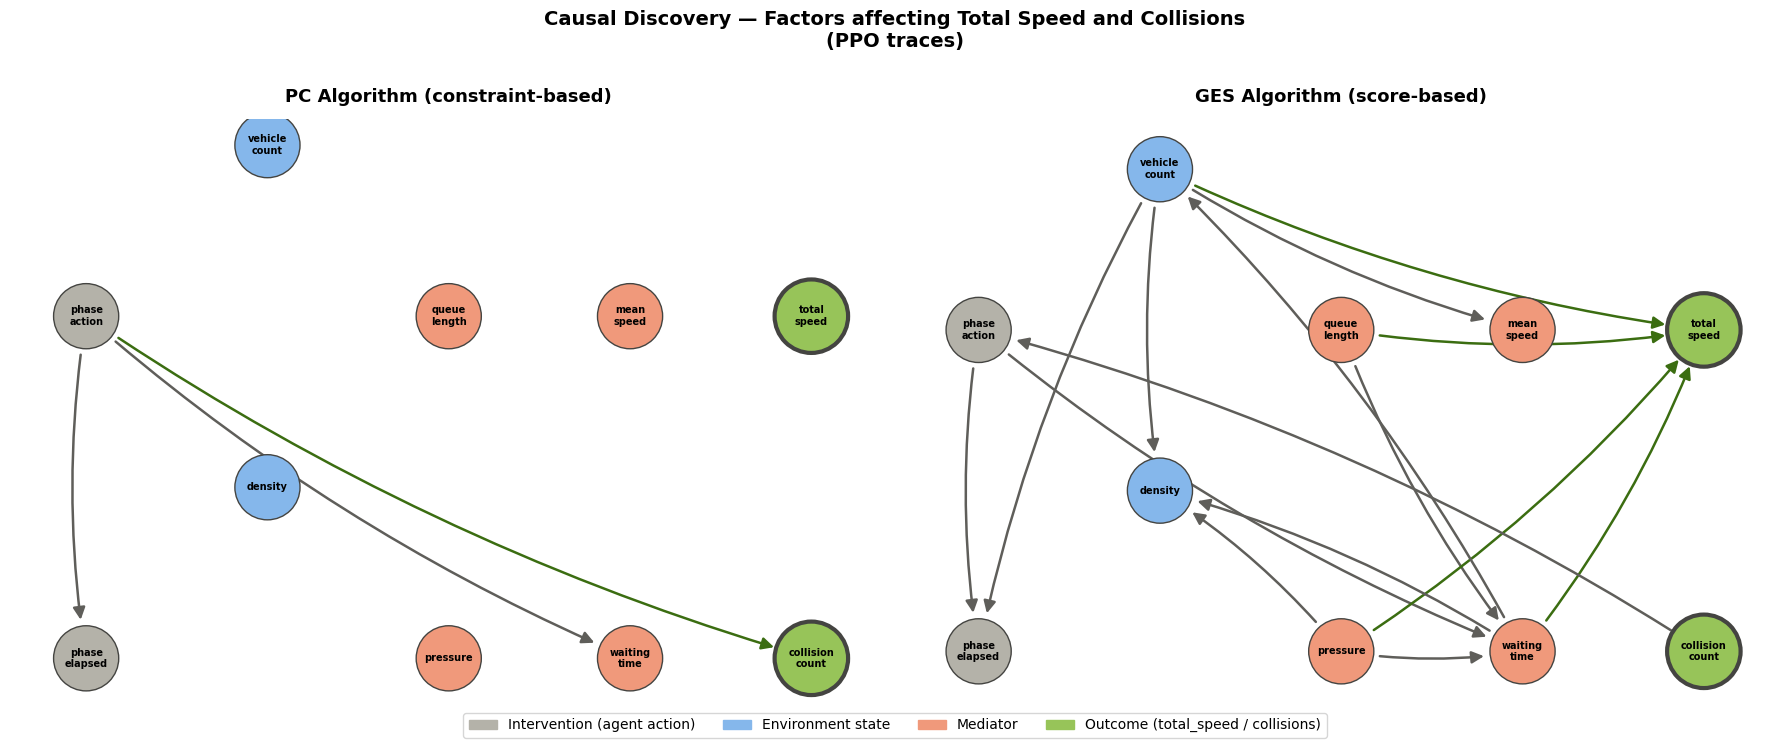


✓ Causal graph saved → d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\causal\causal_discovery.png


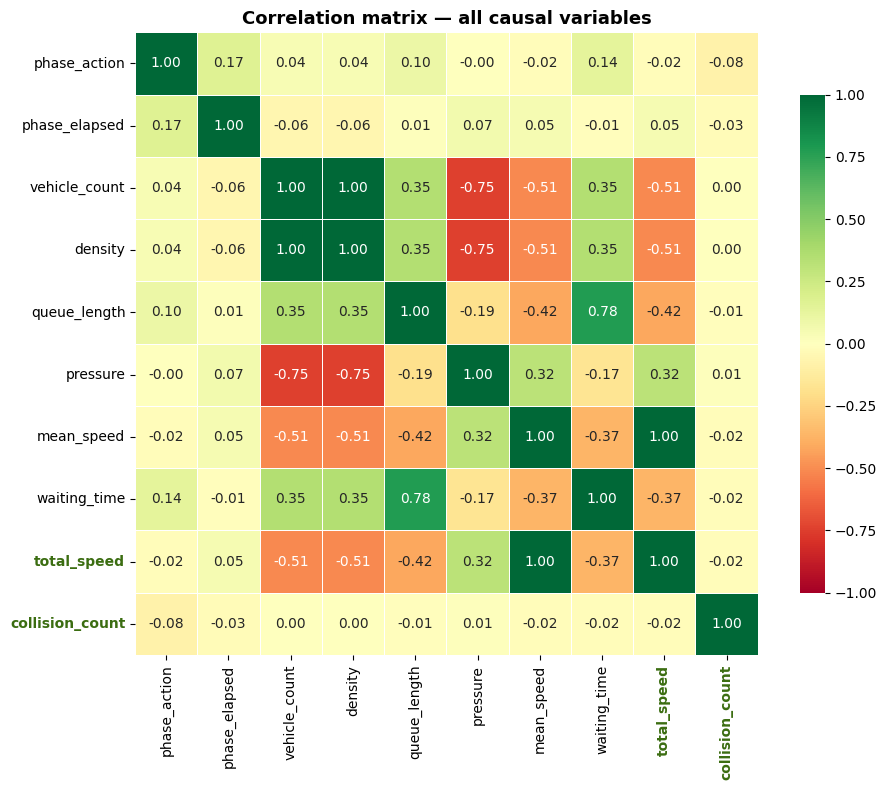

✓ Heatmap saved → d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\causal\correlation_heatmap.png

  SUMMARY
  Trace episodes     : 10
  Total steps logged : 7200
  PC  edges found    : 3
  GES edges found    : 15
  Agreed edges       : 2

  Agreed causal structure:
    phase_action         → phase_elapsed        
    phase_action         → waiting_time         


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL — Environment Tracing + Causal Discovery
#  Run AFTER the PPO training cell. Requires: causallearn, pandas, matplotlib
#  pip install causallearn pandas matplotlib seaborn
# ═══════════════════════════════════════════════════════════════════════════════

# Trace the trained PPO agent to collect environment variables for causal discovery.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
from causallearn.utils.cit import fisherz
from causallearn.graph.GraphNode import GraphNode


# ── Step 1: Collect environment traces ────────────────────────────────────────
print("=" * 60)
print("  STEP 1 — Collecting environment traces")
print("=" * 60)

N_TRACE_EPISODES = 10    # number of episodes to trace
trace_rows       = []

# Load best model saved during training
best_model_path = str(Path(MODEL_DIR) / "best_model.zip")
trace_model     = PPO.load(best_model_path)
print(f"✓ Loaded model from {best_model_path}")

# Raw env for tracing (no VecEnv wrapper so we can access TraCI directly)
trace_env = make_env(OUT_CSV + "_trace")()

for ep in range(N_TRACE_EPISODES):
    obs, _       = trace_env.reset()
    step         = 0
    ep_reward    = 0.0

    while True:
        action, _  = trace_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = trace_env.step(action)

        # ── Access raw SUMO env through Monitor wrapper ────────────────────────
        raw_env = trace_env.env          # Monitor → SumoEnvironment
        ts_id   = raw_env.ts_ids[0]
        ts      = raw_env.traffic_signals[ts_id]

        # ── Trace variables ────────────────────────────────────────────────────
        # Intervention
        phase_action = int(action)

        # Mediators
        mean_speed = float(np.mean([
            ts.sumo.lane.getLastStepMeanSpeed(lane)
            for lane in ts.lanes
        ]))

        total_speed = float(sum([
            ts.sumo.lane.getLastStepMeanSpeed(lane)
            for lane in ts.lanes
        ]))

        queue_length = float(sum(
            ts.sumo.lane.getLastStepHaltingNumber(lane)
            for lane in ts.lanes
        ))

        vehicle_count = float(sum(
            ts.sumo.lane.getLastStepVehicleNumber(lane)
            for lane in ts.lanes
        ))

        density = float(np.mean([
            ts.sumo.lane.getLastStepVehicleNumber(lane) /
            max(ts.sumo.lane.getLength(lane) / 7.5, 1e-6)
            for lane in ts.lanes
        ]))

        # Pressure — handle all return types
        pressure_raw = ts.get_pressure()
        if isinstance(pressure_raw, list):
            pressure = float(sum(pressure_raw))
        elif isinstance(pressure_raw, dict):
            pressure = float(sum(pressure_raw.values()))
        else:
            pressure = float(pressure_raw)

        # Waiting time
        waiting_raw = ts.get_accumulated_waiting_time_per_lane()
        if isinstance(waiting_raw, dict):
            waiting_time = float(sum(waiting_raw.values()))
        elif isinstance(waiting_raw, (int, float)):
            waiting_time = float(waiting_raw)
        else:
            waiting_time = float(sum(waiting_raw))

        # Outcomes
        collision_count = int(len(ts.sumo.simulation.getCollisions()))

        # Phase elapsed (how long current phase has been active)
        phase_elapsed = float(ts.time_since_last_phase_change)

        ep_reward += reward
        trace_rows.append({
            "episode"        : ep,
            "step"           : step,
            "phase_action"   : phase_action,
            "phase_elapsed"  : phase_elapsed,
            "vehicle_count"  : vehicle_count,
            "density"        : round(density,       4),
            "queue_length"   : round(queue_length,  2),
            "pressure"       : round(pressure,      4),
            "mean_speed"     : round(mean_speed,    4),
            "total_speed"    : round(total_speed,   4),   # ← outcome 1
            "waiting_time"   : round(waiting_time,  2),
            "collision_count": collision_count,            # ← outcome 2
            "reward"         : round(float(reward), 6),
        })
        step += 1

        if terminated or truncated:
            print(f"  Episode {ep + 1:02d} | steps: {step:4d} | "
                f"reward: {ep_reward:.3f} | "
                f"collisions: {sum(r['collision_count'] for r in trace_rows if r['episode'] == ep)}")
            break

trace_env.close()

df = pd.DataFrame(trace_rows)
trace_path = str(Path(MODEL_DIR).parent.parent / "causal" / "ppo_traces.csv")
df.to_csv(trace_path, index=False)
print(f"\n✓ Traces saved → {trace_path}")
print(f"  Shape: {df.shape} | Episodes: {N_TRACE_EPISODES}")
print(f"\n{df.describe().round(3)}\n")


# ── Step 2: Prepare data for causal discovery ──────────────────────────────────
print("=" * 60)
print("  STEP 2 — Preparing causal discovery data")
print("=" * 60)

# Variables for causal discovery — all factors + both outcomes
CAUSAL_VARS = [
    "phase_action",     # intervention
    "phase_elapsed",    # intervention context
    "vehicle_count",    # environment state
    "density",          # environment state
    "queue_length",     # mediator
    "pressure",         # mediator
    "mean_speed",       # mediator → affects total_speed
    "waiting_time",     # mediator → affects collisions
    "total_speed",      # ← OUTCOME 1
    "collision_count",  # ← OUTCOME 2
]

df_causal = df[CAUSAL_VARS].copy()

# Standardize — PC and GES work best on normalized data
df_norm = (df_causal - df_causal.mean()) / (df_causal.std() + 1e-8)
data_array = df_norm.values.astype(float)

print(f"✓ Variables : {CAUSAL_VARS}")
print(f"✓ Data shape: {data_array.shape}")
print(f"✓ Correlation with total_speed:")
print(df_causal.corr()["total_speed"].sort_values(ascending=False).round(3).to_string())
print(f"\n✓ Correlation with collision_count:")
print(df_causal.corr()["collision_count"].sort_values(ascending=False).round(3).to_string())


# ── Step 3: Causal discovery — PC algorithm ────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 3 — PC Algorithm (constraint-based)")
print("=" * 60)

cg_pc = pc(
    data_array,
    alpha=0.05,              # significance level for conditional independence tests
    indep_test=fisherz,      # Fisher Z test (appropriate for continuous data)
    stable=True,             # stable PC variant (order-independent skeleton)
    uc_rule=0,               # UC rule for unshielded colliders
    uc_priority=2,
    show_progress=False
)

print("✓ PC algorithm complete")
print(f"  Nodes : {len(CAUSAL_VARS)}")
print(f"  Edges found: {cg_pc.G.get_num_edges()}")


# ── Step 4: Causal discovery — GES algorithm ──────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 4 — GES Algorithm (score-based)")
print("=" * 60)

record_ges = ges(data_array)
cg_ges     = record_ges["G"]

print("✓ GES algorithm complete")
print(f"  Edges found: {cg_ges.get_num_edges()}")


# ── Step 5: Parse edges and identify causal parents ───────────────────────────
print("\n" + "=" * 60)
print("  STEP 5 — Causal parents of outcomes")
print("=" * 60)

def get_edges(cg, var_names):
    """Extract directed edges from a causallearn graph as (cause, effect) pairs."""
    edges   = []
    n       = len(var_names)
    adj     = cg.graph   # adjacency matrix: -1 = tail, 1 = arrowhead

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            # i → j: adj[j,i] == -1 (tail at i) AND adj[i,j] == 1 (arrow at j)
            if adj[j, i] == -1 and adj[i, j] == 1:
                edges.append((var_names[i], var_names[j]))

    return edges

pc_edges  = get_edges(cg_pc.G, CAUSAL_VARS)
ges_edges = get_edges(cg_ges,  CAUSAL_VARS)

# Agreed edges — appear in BOTH algorithms (higher confidence)
agreed_edges = set(pc_edges) & set(ges_edges)

for outcome in ["total_speed", "collision_count"]:
    pc_parents  = [c for c, e in pc_edges  if e == outcome]
    ges_parents = [c for c, e in ges_edges if e == outcome]
    agreed      = [c for c, e in agreed_edges if e == outcome]

    print(f"\n  Outcome: {outcome}")
    print(f"    PC  parents : {pc_parents  if pc_parents  else '(none found)'}")
    print(f"    GES parents : {ges_parents if ges_parents else '(none found)'}")
    print(f"    Agreed      : {agreed      if agreed      else '(none found)'}")


# ── Step 6: Visualise ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 6 — Visualising causal graphs")
print("=" * 60)

# Node role mapping for colour coding
NODE_ROLES = {
    "phase_action"   : "intervention",
    "phase_elapsed"  : "intervention",
    "vehicle_count"  : "environment",
    "density"        : "environment",
    "queue_length"   : "mediator",
    "pressure"       : "mediator",
    "mean_speed"     : "mediator",
    "waiting_time"   : "mediator",
    "total_speed"    : "outcome",
    "collision_count": "outcome",
}

ROLE_COLORS = {
    "intervention": "#B4B2A9",   # gray
    "environment" : "#85B7EB",   # blue
    "mediator"    : "#F0997B",   # coral
    "outcome"     : "#97C459",   # green
}

# Fixed layout positions for consistent rendering
NODE_POS = {
    "phase_action"   : (1.0, 3.5),
    "phase_elapsed"  : (1.0, 2.5),
    "vehicle_count"  : (2.5, 4.0),
    "density"        : (2.5, 3.0),
    "queue_length"   : (4.0, 3.5),
    "pressure"       : (4.0, 2.5),
    "mean_speed"     : (5.5, 3.5),
    "waiting_time"   : (5.5, 2.5),
    "total_speed"    : (7.0, 3.5),
    "collision_count": (7.0, 2.5),
}

def draw_causal_graph(edges, var_names, title, ax):
    import networkx as nx

    G = nx.DiGraph()
    G.add_nodes_from(var_names)

    # Separate directed and undirected edges
    directed   = [(u, v) for u, v in edges]
    undirected = []

    # Check for bidirected (both directions present = undirected in CPDAG)
    edge_set = set(edges)
    for u, v in list(directed):
        if (v, u) in edge_set:
            undirected.append((u, v))

    directed = [(u, v) for u, v in directed if (v, u) not in edge_set]

    G.add_edges_from(directed)

    node_colors = [ROLE_COLORS[NODE_ROLES[n]] for n in var_names]
    pos         = {n: NODE_POS[n] for n in var_names}

    # Highlight outcome nodes with thicker border
    node_sizes      = [2800 if NODE_ROLES[n] == "outcome" else 2200 for n in var_names]
    linewidths      = [3.0  if NODE_ROLES[n] == "outcome" else 1.0  for n in var_names]
    edge_colors_map = ["#3B6D11" if NODE_ROLES.get(v, "") == "outcome"
                    else "#5F5E5A" for u, v in G.edges()]

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        linewidths=linewidths,
        edgecolors="#444441"
    )
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        font_size=7,
        font_weight="bold",
        labels={n: n.replace("_", "\n") for n in var_names}
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        edge_color=edge_colors_map,
        width=1.8,
        connectionstyle="arc3,rad=0.08",
        min_source_margin=28,
        min_target_margin=28,
    )

    # Undirected edges (dashed)
    if undirected:
        drawn = set()
        for u, v in undirected:
            if (v, u) not in drawn:
                ax.annotate(
                    "", xy=pos[v], xytext=pos[u],
                    arrowprops=dict(arrowstyle="-", color="#888780",
                                    lw=1.5, linestyle="dashed")
                )
                drawn.add((u, v))

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Causal Discovery — Factors affecting Total Speed and Collisions\n(PPO traces)",
            fontsize=14, fontweight="bold", y=1.01)

draw_causal_graph(pc_edges,  CAUSAL_VARS, "PC Algorithm (constraint-based)",  axes[0])
draw_causal_graph(ges_edges, CAUSAL_VARS, "GES Algorithm (score-based)",      axes[1])

# Legend
legend_handles = [
    mpatches.Patch(color=ROLE_COLORS["intervention"], label="Intervention (agent action)"),
    mpatches.Patch(color=ROLE_COLORS["environment"],  label="Environment state"),
    mpatches.Patch(color=ROLE_COLORS["mediator"],     label="Mediator"),
    mpatches.Patch(color=ROLE_COLORS["outcome"],      label="Outcome (total_speed / collisions)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
        frameon=True, fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()

fig_path = str(Path(MODEL_DIR).parent.parent / "causal" / "causal_discovery.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ Causal graph saved → {fig_path}")


# ── Step 7: Correlation heatmap ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 8))
corr = df_causal.corr().round(2)

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr, ax=ax2,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
ax2.set_title("Correlation matrix — all causal variables", fontsize=13, fontweight="bold")

# Highlight outcome columns
for label in ax2.get_xticklabels():
    if label.get_text() in ["total_speed", "collision_count"]:
        label.set_color("#3B6D11")
        label.set_fontweight("bold")
for label in ax2.get_yticklabels():
    if label.get_text() in ["total_speed", "collision_count"]:
        label.set_color("#3B6D11")
        label.set_fontweight("bold")

plt.tight_layout()
heatmap_path = str(Path(MODEL_DIR).parent.parent / "causal" / "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Heatmap saved → {heatmap_path}")

print("\n" + "=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"  Trace episodes     : {N_TRACE_EPISODES}")
print(f"  Total steps logged : {len(df)}")
print(f"  PC  edges found    : {len(pc_edges)}")
print(f"  GES edges found    : {len(ges_edges)}")
print(f"  Agreed edges       : {len(agreed_edges)}")
print(f"\n  Agreed causal structure:")
for u, v in sorted(agreed_edges):
    role = "→ OUTCOME" if v in ["total_speed", "collision_count"] else ""
    print(f"    {u:20s} → {v:20s} {role}")